Código para determinar cuantos archivos DICOM hay en la carpeta de estudio:

In [16]:
from pathlib import Path

DATA_DIR = Path("../data/raw/test_studies")

dicom_files = list(DATA_DIR.rglob("*.dcm"))

print (f"archivos encontrados: {len(dicom_files)}")

archivos encontrados: 90


Código para cargar las imágenes:


In [17]:
import pydicom

dicom_studies = dicom_files[0]

dataset = pydicom.dcmread(dicom_studies, stop_before_pixels=True)

print(dataset)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 206
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.211656320229857259150742995635142122704
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002,0013) Implementation Version Name         SH: '0.5'
(0002,0016) Source Application Entity Title     AE: 'POSDA'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'M_FFE', 'M', 'FFE']
(0008,0012) Instance Creation Date              DA: '19930402'
(0008,0013) Instance Creation Time              TM: '125618'
(0008,0014) Instance Creator UID     

In [18]:
print("Patient ID: ", dataset.get("PatientID"))
print("Modality:", dataset.get("Modality"))
print("Study UID:", dataset.get("StudyInstanceUID"))
print("Series UID:", dataset.get("SeriesInstanceUID"))
print("Rows:", dataset.get("Rows"))
print("Columns:", dataset.get("Columns"))

Patient ID:  VS-MC-RC-063
Modality: MR
Study UID: 1.3.6.1.4.1.14519.5.2.1.11784217633835209751588758740160819597
Series UID: 1.3.6.1.4.1.14519.5.2.1.311251873679098488391157318475172879927
Rows: 256
Columns: 256


In [4]:
print("Tiene Pixel Data:", "PixelData" in dataset)

Tiene Pixel Data: True


In [6]:
image = dataset.pixel_array

print("Tipo: ", type(image))
print("Shape: ", image.shape)
print("Dtype: ", image.dtype)


AttributeError: 'MRIStudy' object has no attribute 'pixel_array'

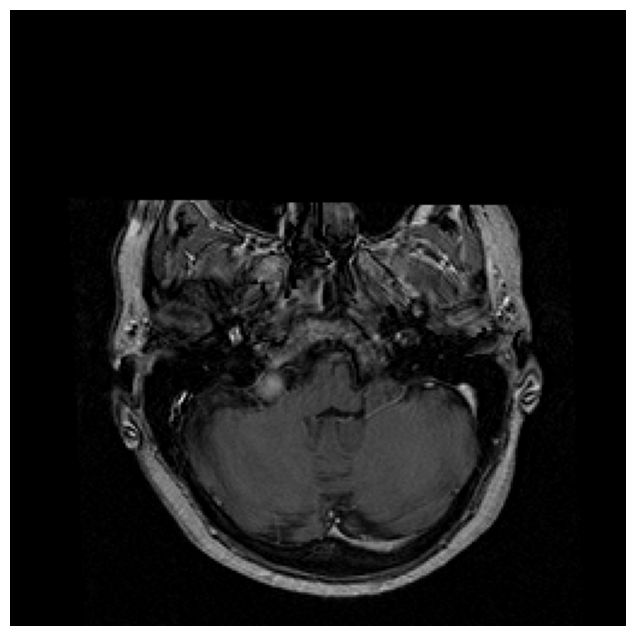

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(image, cmap="gray")

plt.axis("off")
plt.show()

In [ ]:
for path in dicom_files[:10]:
    ds = reader.load_study(path)

    print(
        f"{path.name} | "
        f"Study: {ds.get('StudyInstanceUID')} | "
        f"Series: {ds.get('SeriesInstanceUID')} | "
        f"Modality: {ds.get('Modality')} | "
        f"Instance: {ds.get('InstanceNumber')}"
    )

instance-0001.dcm | Study: 1.3.6.1.4.1.14519.5.2.1.11784217633835209751588758740160819597 | Series: 1.3.6.1.4.1.14519.5.2.1.311251873679098488391157318475172879927 | Modality: MR | Instance: 20
instance-0002.dcm | Study: 1.3.6.1.4.1.14519.5.2.1.11784217633835209751588758740160819597 | Series: 1.3.6.1.4.1.14519.5.2.1.311251873679098488391157318475172879927 | Modality: MR | Instance: 69
instance-0003.dcm | Study: 1.3.6.1.4.1.14519.5.2.1.11784217633835209751588758740160819597 | Series: 1.3.6.1.4.1.14519.5.2.1.311251873679098488391157318475172879927 | Modality: MR | Instance: 52
instance-0004.dcm | Study: 1.3.6.1.4.1.14519.5.2.1.11784217633835209751588758740160819597 | Series: 1.3.6.1.4.1.14519.5.2.1.311251873679098488391157318475172879927 | Modality: MR | Instance: 22
instance-0005.dcm | Study: 1.3.6.1.4.1.14519.5.2.1.11784217633835209751588758740160819597 | Series: 1.3.6.1.4.1.14519.5.2.1.311251873679098488391157318475172879927 | Modality: MR | Instance: 25
instance-0006.dcm | Study: 1.3

In [ ]:
studies = {}

for path in dicom_files:
    ds = reader.load_study(path)

    study_uid = ds.get("StudyInstanceUID")

    if study_uid:
        studies.setdefault(study_uid, []).append(path)

print(f"Estudios encontrados: {len(studies)}")

for study_uid, files in studies.items():
    print(f"Study {study_uid}: {len(files)} archivos")

Estudios encontrados: 1
Study 1.3.6.1.4.1.14519.5.2.1.11784217633835209751588758740160819597: 90 archivos


In [10]:
series = {}

for path in dicom_files:
    ds = pydicom.dcmread(path, stop_before_pixels=True)

    series_uid = ds.get("SeriesInstanceUID")

    if series_uid:
        series.setdefault(series_uid, []).append(path)

print(f"Series encontradas: {len(series)}")

for series_uid, files in series.items():
    print(f"Series {series_uid}: {len(files)} archivos")

Series encontradas: 1
Series 1.3.6.1.4.1.14519.5.2.1.311251873679098488391157318475172879927: 90 archivos
